![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [ ]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [ ]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [ ]:
# Celda 1
#Librerías
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Conversión de variables predictoras a numéricas
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Función para calcular el MSE de un nodo
def mse_node(y):
    if y.shape[0] == 0:
        return 0
    else:
        return np.mean((y - y.mean())**2)

# Función para calcular la reducción del MSE
def mse_impurity(X_col, y, split):

    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]

    n_l = y_l.shape[0]
    n_r = y_r.shape[0]

    mse_y = mse_node(y)
    mse_l = mse_node(y_l)
    mse_r = mse_node(y_r)

    mse_reduction = mse_y - (n_l / (n_l + n_r) * mse_l + n_r / (n_l + n_r) * mse_r)

    return mse_reduction

# Función para obtener la mejor variable y punto de corte
def best_split(X, y, num_pct=10):

    features = range(X.shape[1])
    best_split = [0, 0, 0]  # j, split, gain

    # Iteración sobre variables
    for j in features:

        x_j = X.iloc[:, j].astype(float)
        splits = np.percentile(x_j, np.arange(0, 100, 100.0 / (num_pct + 1)).tolist())
        splits = np.unique(splits)[1:]

        # Iteración sobre puntos de corte
        for split in splits:
            gain = mse_impurity(x_j, y, split)

            if gain > best_split[2]:
                best_split = [j, split, gain]

    return best_split

# Función para construir el árbol de forma recursiva
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=3, num_pct=10):

    # Caso de una sola observación
    if X.shape[0] == 1:
        tree = dict(y_pred=y.iloc[0], level=level, split=-1, n_samples=1, gain=0)
        return tree

    # Caso de respuesta constante
    if y.nunique() == 1:
        tree = dict(y_pred=y.iloc[0], level=level, split=-1, n_samples=y.shape[0], gain=0)
        return tree

    # Mejor división
    j, split, gain = best_split(X, y, num_pct)

    # Nodo actual
    y_pred = y.mean()
    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], gain=gain)

    # Criterio de parada por ganancia
    if gain < min_gain:
        return tree

    # Criterio de parada por profundidad
    if max_depth is not None:
        if level >= max_depth:
            return tree

    # Partición de datos
    filter_l = X.iloc[:, j].astype(float) < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]

    # Validación de ramas vacías
    if X_l.shape[0] == 0 or X_r.shape[0] == 0:
        return tree

    tree['split'] = [j, split]

    # Crecimiento recursivo
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)

    return tree

# Función para realizar predicciones con el árbol
def tree_predict(X, tree):

    predicted = np.ones(X.shape[0])

    # Nodo terminal
    if tree['split'] == -1:
        predicted = predicted * tree['y_pred']

    else:
        j, split = tree['split']
        filter_l = X.iloc[:, j].astype(float) < split

        X_l = X.loc[filter_l]
        X_r = X.loc[~filter_l]

        if X_l.shape[0] == 0:
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])
        elif X_r.shape[0] == 0:
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
        else:
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])

    return predicted

# Construcción del árbol manual
tree_manual = tree_grow(X_train, y_train, level=0, min_gain=0.001, max_depth=3, num_pct=10)

# Predicción sobre el set de test
y_pred_manual = tree_predict(X_test, tree_manual)

# Cálculo de métricas
rmse_manual = np.sqrt(mean_squared_error(y_test, y_pred_manual))
mae_manual = mean_absolute_error(y_test, y_pred_manual)

print("RMSE árbol manual:", rmse_manual)
print("MAE árbol manual:", mae_manual)

# Primer split del árbol
feature_names = X_train.columns
j, split = tree_manual['split']

print("\nPrimer split del árbol:")
print("Variable:", feature_names[j])
print("Punto de corte:", split)

# Comparación real vs predicho
results = pd.DataFrame({
    "Real": y_test,
    "Predicho": y_pred_manual
})
print("\nResultados obtenidos vs valor real")
print(results)

RMSE árbol manual: 1921.0003286740268
MAE árbol manual: 1445.8091325887447

Primer split del árbol:
Variable: Year
Punto de corte: 2014.0

Resultados obtenidos vs valor real
         Real      Predicho
257343   9900  13964.065463
326011   6987   7776.186164
242354  15814  16704.304998
266376  17997  16704.304998
396954  18938  16704.304998
...       ...           ...
144298  17988  15102.596078
364521  19995  16704.304998
120072  18330  18798.415621
99878   10495  11667.545946
387162  12995  11667.545946

[3464 rows x 2 columns]


El árbol de decisión manual obtuvo un RMSE de 1921.0032 y un MAE de 1445.8091 en el conjunto de test. Por lo tanto el modelo logra capturar parte del comportamiento del precio de los automóviles, pero todavía presenta errores relativamente altos. En este caso, el MAE indica que, en promedio, la predicción se desvía del precio real en alrededor de 1446 unidades monetarias, mientras que el RMSE es mayor porque penaliza más fuertemente los errores grandes.

Adicionalmente, el **primer split del árbol** se realiza sobre la variable **Year** con un punto de corte en 2014, lo que indica que el modelo considera el año del vehículo como la variable más relevante para explicar el precio.

### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [ ]:
# Celda 2
#Librearías
from sklearn.tree import DecisionTreeRegressor
import pandas as pd

# Número de observaciones de entrenamiento
n_samples = X_train.shape[0]

# Número de árboles
n_B = 10

# Semilla
np.random.seed(123)

# Creación de muestras bootstrap
samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(n_B)]

# Definición del modelo base
treereg = DecisionTreeRegressor(max_depth=None, random_state=123)

# DataFrame para guardar predicciones
y_pred = pd.DataFrame(index=X_test.index, columns=list(range(n_B)))

# Entrenamiento de un árbol sobre cada muestra bootstrap
for i, sample in enumerate(samples):
    X_train_boot = X_train.iloc[sample, :]
    y_train_boot = y_train.iloc[sample]

    treereg.fit(X_train_boot, y_train_boot)
    y_pred.iloc[:, i] = treereg.predict(X_test)

# Predicción final del bagging manual
y_pred_bagging_manual = y_pred.mean(axis=1)

# Cálculo de métricas
rmse_bagging_manual = np.sqrt(mean_squared_error(y_test, y_pred_bagging_manual))
mae_bagging_manual = mean_absolute_error(y_test, y_pred_bagging_manual)

print("RMSE Bagging manual:", rmse_bagging_manual)
print("MAE Bagging manual:", mae_bagging_manual)

RMSE Bagging manual: 1796.4355868399332
MAE Bagging manual: 1340.0160739030025


El modelo de bagging manual con 10 árboles de regresión obtuvo un RMSE de 1796.44 y un MAE de 1340.02. Comparado con el árbol de decisión manual del punto anterior, se observa una mejora en ambas métricas, lo que indica que el bagging ayuda a reducir el error de predicción. Esto ocurre ya que al promedio las predicciones de varios árboles entrenados sobre muestras bootstrap distintas, se reduce la varianza del modelo y se obtiene una predicción más estable. En este caso, el bagging manual logra un mejor desempeño que el árbol individual.




### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [ ]:
# Celda 3
#Librerías
from sklearn.ensemble import BaggingRegressor

# Número de variables predictoras
n_features = X_train.shape[1]

# Definición de max_features = log(n_features)
max_features = max(1, int(np.log(n_features)))

# Definición del modelo base
tree = DecisionTreeRegressor(max_features=max_features, random_state=42)

# Definición del modelo bagging
bagreg = BaggingRegressor(
    estimator=tree,
    n_estimators=10,
    bootstrap=True,
    random_state=42
)

# Entrenamiento del modelo
bagreg.fit(X_train, y_train)

# Predicción sobre el set de test
y_pred_bagging = bagreg.predict(X_test)

# Evaluación del modelo
rmse_bagging = np.sqrt(mean_squared_error(y_test, y_pred_bagging))
mae_bagging = mean_absolute_error(y_test, y_pred_bagging)

print("RMSE Bagging:", rmse_bagging)
print("MAE Bagging:", mae_bagging)

print("\nNúmero de variables:", n_features)
print("max_features usado:", max_features)

RMSE Bagging: 1813.0409476471518
MAE Bagging: 1353.424136561091

Número de variables: 9
max_features usado: 2


El modelo de bagging con librería obtuvo un RMSE de 1813.04 y un MAE de 1353.42. En comparación con el árbol de decisión manual, este modelo sigue mostrando una mejora, lo que confirma que el uso de ensambles ayuda a reducir la varianza y mejorar la estabilidad de las predicciones. Sin embargo, frente al bagging manual del punto anterior, el desempeño es ligeramente inferior. Esto puede deberse a la configuración de parámetro max_features = log(n_features), ya que al limitar el número de variables consideradas en cada árbol base, se introduce más aleatoriedad, pero no necesariamente una mejora en este conjunto de datos. En este caso, el modelo sigue siendo teniendo un buen nivel de predictividad, pero no supera al bagging manual.


### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

In [ ]:
# Celda 4
#Librerías
from sklearn.ensemble import RandomForestRegressor

# Definición del modelo Random Forest para regresión
rf = RandomForestRegressor(random_state=42)

# Entrenamiento del modelo
rf.fit(X_train, y_train)

# Predicción sobre el set de test
y_pred_rf = rf.predict(X_test)

# Evaluación del modelo
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("RMSE Random Forest:", rmse_rf)
print("MAE Random Forest:", mae_rf)

print("\nNúmero de árboles:", rf.n_estimators)

RMSE Random Forest: 1765.4118259983413
MAE Random Forest: 1314.4207078056425

Número de árboles: 100


El modelo de Random Forest obtuvo un RMSE de 1765.41 y un MAE de 1314.42,   lo que representa una mejora frente al árbol manual, el bagging manual y el bagging con librería. Esto sugiere que Random Forest logra capturar mejor la relación entre las variables predictoras y el precio del automóvil. La mejora tiene sentido porque, además de usar bootstrap como en bagging, Random Forest introduce aleatoriedad en la selección de variables en cada partición, lo cual ayuda a reducir la correlación entre árboles y mejora la capacidad predictiva del ensamble. En este caso, el modelo muestra un mejor desempeño general.

### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

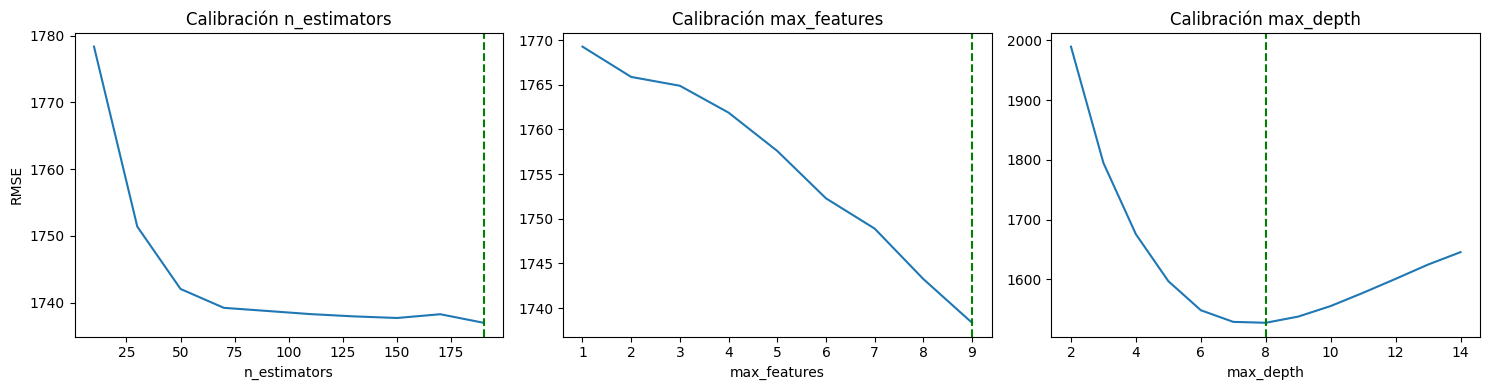


Mejor n_estimators: 190
Mejor max_features: 9
Mejor max_depth: 8

Métricas Random Forest calibrado
MSE Random Forest calibrado: 1564.9032827182186
MAE Random Forest calibrado: 1150.4995758544605


In [ ]:
# Celda 5
#Librerías
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

#Calibración max_depth
depth_range = range(2, 15)
rmse_depth = []

for depth in depth_range:

    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    scores = cross_val_score(
        rf,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    rmse_depth.append(np.sqrt(-scores.mean()))


#Calibración max_features
feature_range = range(1, X_train.shape[1] + 1)
rmse_features = []

for feature in feature_range:

    rf = RandomForestRegressor(
        n_estimators=100,
        max_features=feature,
        random_state=42
    )

    scores = cross_val_score(
        rf,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    rmse_features.append(np.sqrt(-scores.mean()))


#Calibración n_estimators
estimator_range = range(10, 210, 20)
rmse_estimators = []

for estimator in estimator_range:

    rf = RandomForestRegressor(
        n_estimators=estimator,
        random_state=42
    )

    scores = cross_val_score(
        rf,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    rmse_estimators.append(np.sqrt(-scores.mean()))


#Gráfica
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# n_estimators
best_estimator = estimator_range[np.argmin(rmse_estimators)]
axes[0].plot(estimator_range, rmse_estimators)
axes[0].axvline(x=best_estimator, linestyle="--", color="green")
axes[0].set_title("Calibración n_estimators")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("RMSE")

# max_features
best_features = feature_range[np.argmin(rmse_features)]
axes[1].plot(feature_range, rmse_features)
axes[1].axvline(x=best_features, linestyle="--", color="green")
axes[1].set_title("Calibración max_features")
axes[1].set_xlabel("max_features")

# max_depth
best_depth = depth_range[np.argmin(rmse_depth)]
axes[2].plot(depth_range, rmse_depth)
axes[2].axvline(x=best_depth, linestyle="--", color="green")
axes[2].set_title("Calibración max_depth")
axes[2].set_xlabel("max_depth")

plt.tight_layout()
plt.show()

print("\nMejor n_estimators:", best_estimator)
print("Mejor max_features:", best_features)
print("Mejor max_depth:", best_depth)

#Modelo con parámetros calibrados
rf_tuned = RandomForestRegressor(
    n_estimators=190,
    max_features=9,
    max_depth=8,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

y_pred_rf_tuned = rf_tuned.predict(X_test)

rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)

print("\nMétricas Random Forest calibrado")
print("MSE Random Forest calibrado:", rmse_rf_tuned)
print("MAE Random Forest calibrado:", mae_rf_tuned)

Luego de calibrar los parámetros **n_estimators, max_features y max_depth** del modelo Random Forest, se identificó que los valores óptimos corresponden aproximadamente a n_estimators = 190, max_features = 9 y max_depth = 8, ya que estos valores minimizan el RMSE.

Las gráficas muestran que el error disminuye al aumentar el número de árboles, aunque la mejora se vuelve marginal después de cierto punto. En el caso de max_features, el mejor desempeño se obtiene cuando se consideran más variables en cada partición, lo que permite capturar mejor la relación entre las características del vehículo y su precio. Por su parte, max_depth muestra que el error disminuye hasta una profundidad cercana a 8 niveles y luego vuelve a aumentar, lo que sugiere la presencia de sobreajuste cuando los árboles se vuelven demasiado profundos.

Al entrenar el modelo con estos parámetros calibrados, el Random Forest obtuvo un RMSE de aproximadamente 1564.9 y un MAE de 1150.49, lo que representa una mejora respecto al modelo anterior sin calibración. Esto indica que la optimización de hiperparámetros permite mejorar la capacidad predictiva del modelo.

### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [ ]:
# Celda 6
#Librerías
from xgboost import XGBRegressor

# Definición del modelo
xgb = XGBRegressor(random_state=42)

# Entrenamiento
xgb.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test)

# Métricas
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("RMSE XGBoost:", rmse_xgb)
print("MAE XGBoost:", mae_xgb)

# Importancia de variables
importancia = pd.Series(xgb.feature_importances_, index=X_train.columns)
importancia = importancia.sort_values(ascending=False)
print("\nImportancia de Variables")
print(importancia)

RMSE XGBoost: 1605.2354967418332
MAE XGBoost: 1185.227294921875

Importancia de Variables
Year           0.671126
M_CamryXLE     0.095164
Mileage        0.081629
M_Camry        0.055361
M_CamryLE      0.045928
M_CamrySE      0.019953
M_CamryL       0.013262
M_CamryBase    0.009986
M_Camry4dr     0.007591
dtype: float32


Se implementó un modelo de regresión utilizando XGBoost, un algoritmo de ensamble basado en boosting que construye los árboles de forma secuencial, donde cada nuevo árbol busca corregir los errores del anterior.

El modelo obtuvo un RMSE de aproximadamente 1605.24 y un MAE de 1185.23. Estos resultados representan una mejora respecto a los modelos iniciales como el árbol de decisión y los modelos de bagging, lo que indica que XGBoost logra capturar de forma más eficiente la relación entre las variables predictoras y el precio del automóvil. Sin embargo, al compararlo con el Random Forest calibrado, el desempeño es ligeramente inferior.

El análisis de importancia de variables muestra que **Year** es la variable con mayor influencia en la predicción, con una importancia cercana al 67%. Esto indica que la antigüedad del vehículo es el factor más determinante en el valor de los automóviles.

### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

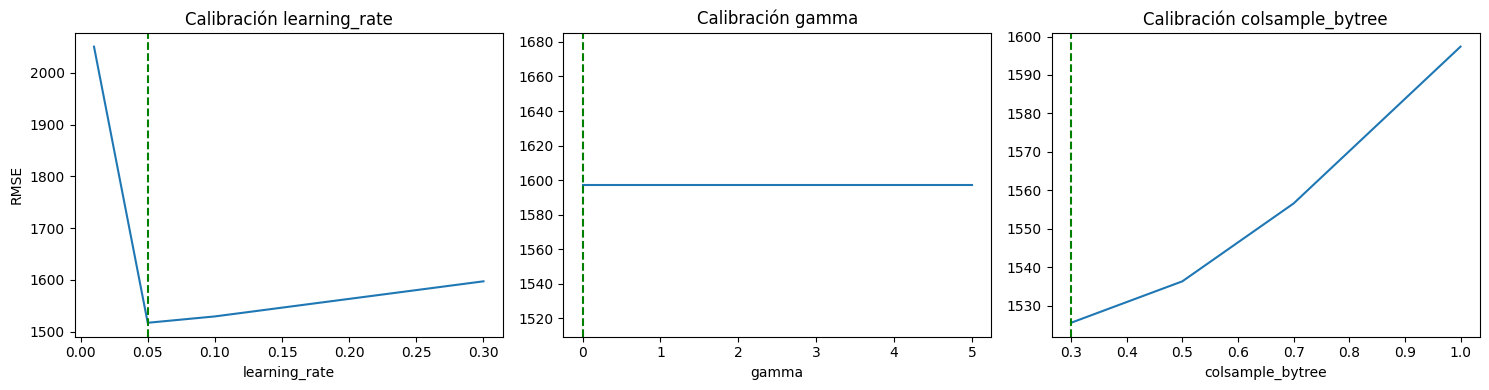


Mejor learning_rate: 0.05
Mejor gamma: 0
Mejor colsample_bytree: 0.3

Métricas XGBoost calibrado
RMSE XGBoost calibrado: 1618.0362325980218
MAE XGBoost calibrado: 1202.6561279296875


In [ ]:
# Celda 7

#learning_rate
lr_range = [0.01, 0.05, 0.1, 0.2, 0.3]
rmse_lr = []

for lr in lr_range:

    xgb = XGBRegressor(
        learning_rate=lr,
        random_state=42
    )

    scores = cross_val_score(
        xgb,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    rmse_lr.append(np.sqrt(-scores.mean()))


#gamma
gamma_range = [0, 0.5, 1, 2, 5]
rmse_gamma = []

for g in gamma_range:

    xgb = XGBRegressor(
        gamma=g,
        random_state=42
    )

    scores = cross_val_score(
        xgb,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    rmse_gamma.append(np.sqrt(-scores.mean()))


#colsample_bytree
colsample_range = [0.3, 0.5, 0.7, 1]
rmse_colsample = []

for col in colsample_range:

    xgb = XGBRegressor(
        colsample_bytree=col,
        random_state=42
    )

    scores = cross_val_score(
        xgb,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    rmse_colsample.append(np.sqrt(-scores.mean()))

#Gráfica
fig, axes = plt.subplots(1, 3, figsize=(15,4))

#mejores valores
best_lr = lr_range[np.argmin(rmse_lr)]
best_gamma = gamma_range[np.argmin(rmse_gamma)]
best_col = colsample_range[np.argmin(rmse_colsample)]

#learning_rate
axes[0].plot(lr_range, rmse_lr)
axes[0].axvline(best_lr, linestyle="--", color="green")
axes[0].set_title("Calibración learning_rate")
axes[0].set_xlabel("learning_rate")
axes[0].set_ylabel("RMSE")

#gamma
axes[1].plot(gamma_range, rmse_gamma)
axes[1].axvline(best_gamma, linestyle="--", color="green")
axes[1].set_title("Calibración gamma")
axes[1].set_xlabel("gamma")

#colsample_bytree
axes[2].plot(colsample_range, rmse_colsample)
axes[2].axvline(best_col, linestyle="--", color="green")
axes[2].set_title("Calibración colsample_bytree")
axes[2].set_xlabel("colsample_bytree")

plt.tight_layout()
plt.show()

print("\nMejor learning_rate:", best_lr)
print("Mejor gamma:", best_gamma)
print("Mejor colsample_bytree:", best_col)

#Modelo con parámetros calibrados
xgb_tuned = XGBRegressor(
    learning_rate=best_lr,
    gamma=best_gamma,
    colsample_bytree=best_col,
    random_state=42
)

xgb_tuned.fit(X_train, y_train)

y_pred_xgb_tuned = xgb_tuned.predict(X_test)

rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)

print("\nMétricas XGBoost calibrado")
print("RMSE XGBoost calibrado:", rmse_xgb_tuned)
print("MAE XGBoost calibrado:", mae_xgb_tuned)

Luego de calibrar los parámetros **learning_rate, gamma y colsample_bytree** del modelo XGBoost, se identificó que los valores que minimizan el error corresponden aproximadamente a learning_rate = 0.05, gamma = 0 y colsample_bytree = 0.3.

El parámetro learning_rate controla la velocidad de aprendizaje del modelo, donde valores moderados permiten un ajuste más estable. El parámetro gamma regula la complejidad de las divisiones en los árboles; en este caso el mejor valor fue 0, lo que indica que permitir divisiones más flexibles. Finalmente, colsample_bytree controla la proporción de variables utilizadas en cada árbol.

Al entrenar el modelo con estos parámetros calibrados se obtiene un desempeño similar al modelo inicial, lo que sugiere que la calibración de estos hiperparámetros no genera una mejora significativa en este caso.

### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

In [ ]:
# Celda 8
resultados = pd.DataFrame({
    "Modelo": [
        "Árbol manual",
        "Bagging manual",
        "Bagging sklearn",
        "Random Forest",
        "Random Forest calibrado",
        "XGBoost",
        "XGBoost calibrado"
    ],

    "RMSE": [
        rmse_manual,
        rmse_bagging_manual,
        rmse_bagging,
        rmse_rf,
        rmse_rf_tuned,
        rmse_xgb,
        rmse_xgb_tuned
    ],

    "MAE": [
        mae_manual,
        mae_bagging_manual,
        mae_bagging,
        mae_rf,
        mae_rf_tuned,
        mae_xgb,
        mae_xgb_tuned
    ]
})

resultados = resultados.sort_values("RMSE")

resultados

,Modelo,RMSE,MAE
4,Random Forest calibrado,1564.903283,1150.499576
5,XGBoost,1605.235497,1185.227295
6,XGBoost calibrado,1618.036233,1202.656128
3,Random Forest,1765.411826,1314.420708
1,Bagging manual,1796.435587,1340.016074
2,Bagging sklearn,1813.040948,1353.424137
0,Árbol manual,1921.000329,1445.809133


Dados los resultados de los modelos implementados, se observa que el **Random Forest calibrado** presenta el mejor desempeño, al obtener los menores valores en las métricas RMSE y MAE. Esto refleja su capacidad para capturar patrones complejos en los datos mediante la combinación de múltiples árboles y la reducción de la varianza.

Dentro de las principales ventajas de este modelo podemos destacar su robustez frente a variaciones en los datos, su capacidad para manejar relaciones no lineales y un menor riesgo de sobreajuste en comparación con modelos individuales, esto debio a la aleatoriedad en la selección de muestras y variables.

Por otro lado, podemos destacar de modelos como XGBoost su capacidad de reducir el sesgo mediante aprendizaje secuencial, sin embargo se requiere un mayor ajuste para alcanzar su máximo potencial.

Por último, el modelo con menor desempeño fue el **árbol de decisión manual**, ya que presentó los mayores valores de error que podría deberse a su limitada capacidad para capturar la complejidad de los datos, ya que se basa en reglas definidas manualmente y no optimiza de manera sistemática los puntos de corte. Además también hay que tener en cuenta que este tipo de modelo es más propenso a errores de especificación puesto que no aprovecha las ventajas de los métodos de ensamblaje.